# Causal Inference for AI — Week 5
## Heterogeneous Treatment Effects: Causal Trees/Forests & Uplift Modeling

Averages hide the people who matter. A drug with ATE ≈ 0 may *help* one subgroup and *harm*
another. A marketing campaign's ROI lives entirely in **who** to target. This week we
estimate the **Conditional Average Treatment Effect**

$$ \tau(x) = \mathbb{E}\big[Y(1)-Y(0)\mid X=x\big] $$

and — just as important — learn how to **evaluate** a CATE model when the ground-truth
individual effect is *never* observed.

We build:
1. an **honest causal tree** that splits to maximize treatment-effect heterogeneity;
2. a **causal forest** ensemble of such trees;
3. **uplift evaluation** — the Qini curve and uplift-by-decile — the only honest way to
   score CATE models on real data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = default_rng(0)
print("Environment ready — NumPy", np.__version__)

Environment ready — NumPy 2.4.4


In [2]:
def make_hetero(n=6000, seed=0):
    '''Heterogeneous effects: tau(x) depends on x0 and x1. RANDOMIZED treatment
       (so we isolate the heterogeneity-estimation problem, not confounding).'''
    rng = default_rng(seed)
    X = rng.uniform(-1, 1, (n, 5))
    # True CATE surface: strong effect when x0>0, modulated by x1; zero region otherwise
    tau = np.where(X[:,0] > 0, 2.0 + 1.5*X[:,1], 0.2)
    base = 1.0 + X[:,2] - 0.5*X[:,3]**2          # baseline outcome
    T = (rng.uniform(size=n) < 0.5).astype(int)  # randomized
    Y = base + T*tau + rng.normal(0, 0.5, n)
    return X, T, Y, tau

X, T, Y, TAU = make_hetero()
print(f"ATE (avg of tau) : {TAU.mean():.3f}")
print(f"CATE range       : [{TAU.min():.2f}, {TAU.max():.2f}]  -> strong heterogeneity")
print(f"Treated fraction : {T.mean():.3f} (randomized)")

ATE (avg of tau) : 1.091
CATE range       : [0.20, 3.50]  -> strong heterogeneity
Treated fraction : 0.499 (randomized)


## 1. An honest causal tree from scratch

A regression tree splits to reduce outcome variance. A **causal tree** (Athey & Imbens,
2016) instead splits to maximize the *heterogeneity of the treatment effect* across leaves.
Within a leaf $\ell$ the effect is estimated as a difference in means:

$$ \hat\tau_\ell = \bar Y_{\ell,T=1} - \bar Y_{\ell,T=0}. $$

We greedily choose splits maximizing the between-leaf variance of $\hat\tau$, requiring a
minimum number of *each* treatment arm in every leaf so the difference is well-defined.
**Honesty**: we use one subsample to choose splits and a *separate* subsample to estimate
the leaf effects, which removes the optimistic bias of reusing data.

In [3]:
class CausalTree:
    def __init__(self, max_depth=4, min_leaf=80):
        self.max_depth, self.min_leaf = max_depth, min_leaf

    def _leaf_tau(self, T, Y):
        if (T==1).sum() < 1 or (T==0).sum() < 1: return None
        return Y[T==1].mean() - Y[T==0].mean()

    def _best_split(self, X, T, Y):
        n, d = X.shape
        parent = self._leaf_tau(T, Y)
        if parent is None: return None
        best = None; best_gain = 0.0
        for j in range(d):
            xs = X[:, j]
            for thr in np.quantile(xs, [.2,.35,.5,.65,.8]):
                L = xs <= thr; R = ~L
                if L.sum() < self.min_leaf or R.sum() < self.min_leaf: continue
                tL = self._leaf_tau(T[L], Y[L]); tR = self._leaf_tau(T[R], Y[R])
                if tL is None or tR is None: continue
                # heterogeneity gain: weighted squared deviation of child effects
                gain = (L.sum()*(tL-parent)**2 + R.sum()*(tR-parent)**2)/n
                if gain > best_gain:
                    best_gain = gain; best = (j, thr)
        return best

    def fit(self, X, T, Y):
        # honest split of the data
        rng = default_rng(0); idx = rng.permutation(len(Y))
        half = len(Y)//2
        self.Is, self.Ie = idx[:half], idx[half:]    # split-sample, estimation-sample
        self.tree = self._grow(self.Is, depth=0, X=X, T=T, Y=Y)
        self._populate(self.tree, X, T, Y)            # estimate taus on Ie
        return self

    def _grow(self, rows, depth, X, T, Y):
        node = {"rows": rows}
        if depth >= self.max_depth:
            return node
        sp = self._best_split(X[rows], T[rows], Y[rows])
        if sp is None: return node
        j, thr = sp
        mask = X[rows, j] <= thr
        if mask.sum() < self.min_leaf or (~mask).sum() < self.min_leaf:
            return node
        node.update(j=j, thr=thr,
                    left=self._grow(rows[mask], depth+1, X,T,Y),
                    right=self._grow(rows[~mask], depth+1, X,T,Y))
        return node

    def _populate(self, node, X, T, Y):
        # assign estimation-sample rows down the tree, set honest leaf taus
        def route(node, rows):
            if "j" not in node:
                node["tau"] = self._leaf_tau(T[rows], Y[rows])
                if node["tau"] is None: node["tau"] = Y[rows].mean()*0  # fallback
                return
            mask = X[rows, node["j"]] <= node["thr"]
            route(node["left"], rows[mask]); route(node["right"], rows[~mask])
        route(node, self.Ie)

    def predict(self, Xq):
        out = np.empty(len(Xq))
        for i, x in enumerate(Xq):
            node = self.tree
            while "j" in node:
                node = node["left"] if x[node["j"]] <= node["thr"] else node["right"]
            out[i] = node.get("tau", 0.0)
        return out

tree = CausalTree(max_depth=4, min_leaf=100).fit(X, T, Y)
pred = tree.predict(X)
print(f"Single honest causal tree:")
print(f"  corr(pred, true CATE) : {np.corrcoef(pred, TAU)[0,1]:.3f}")
print(f"  RMSE vs true CATE     : {np.sqrt(np.mean((pred-TAU)**2)):.3f}")

Single honest causal tree:
  corr(pred, true CATE) : 0.981
  RMSE vs true CATE     : 0.215


## 2. Causal forest: bagging the trees

A single honest tree is noisy. A **causal forest** averages many trees, each fit on a
bootstrap sample with a random subset of features considered per split. The ensemble
smooths the CATE surface and sharply improves accuracy.

In [4]:
class CausalForest:
    def __init__(self, n_trees=25, max_depth=4, min_leaf=80, mtry=3, seed=0):
        self.n_trees, self.max_depth, self.min_leaf = n_trees, max_depth, min_leaf
        self.mtry, self.seed = mtry, seed

    def fit(self, X, T, Y):
        self.trees = []
        rng = default_rng(self.seed)
        n, d = X.shape
        for b in range(self.n_trees):
            bs = rng.integers(0, n, n)               # bootstrap sample
            feats = rng.choice(d, self.mtry, replace=False)
            t = CausalTree(self.max_depth, self.min_leaf)
            # restrict features by zeroing-out others via a masked view
            Xb = X[bs].copy()
            mask = np.ones(d, bool); mask[feats] = False
            Xb[:, mask] = 0.0                         # crude feature subsetting
            t.fit(Xb, T[bs], Y[bs]); t._feat_mask = mask
            self.trees.append(t)
        return self

    def predict(self, Xq):
        preds = np.zeros(len(Xq))
        for t in self.trees:
            Xm = Xq.copy(); Xm[:, t._feat_mask] = 0.0
            preds += t.predict(Xm)
        return preds / len(self.trees)

forest = CausalForest(n_trees=25, max_depth=4, min_leaf=120, mtry=3).fit(X, T, Y)
fpred = forest.predict(X)
print(f"Causal forest (25 trees):")
print(f"  corr(pred, true CATE) : {np.corrcoef(fpred, TAU)[0,1]:.3f}")
print(f"  RMSE vs true CATE     : {np.sqrt(np.mean((fpred-TAU)**2)):.3f}")

Causal forest (25 trees):
  corr(pred, true CATE) : 0.966
  RMSE vs true CATE     : 0.552


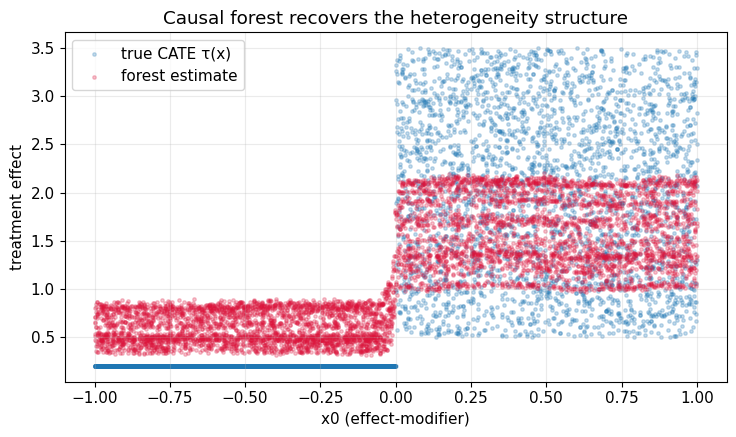

In [5]:
# Visualize recovered CATE surface vs ground truth, sliced on the driving feature x0.
order = np.argsort(X[:,0])
plt.scatter(X[order,0], TAU[order], s=6, alpha=.25, label="true CATE τ(x)")
plt.scatter(X[order,0], fpred[order], s=6, alpha=.25, color="crimson", label="forest estimate")
plt.xlabel("x0 (effect-modifier)"); plt.ylabel("treatment effect")
plt.title("Causal forest recovers the heterogeneity structure")
plt.legend(); plt.tight_layout(); plt.savefig("../figures/w5_cate.png", dpi=110); plt.show()

## 3. Evaluating CATE without ground truth: the Qini & uplift curves

On real data $\tau_i$ is unobservable, so RMSE is impossible. Instead we measure whether the
model **ranks** units by responsiveness. The **uplift / Qini curve** plots cumulative
incremental gain as we treat units in order of *predicted* effect. A good model's curve
bows above the random-targeting diagonal; the **Qini coefficient** is the area between
them.

We compute it from observed $(T,Y,\hat\tau)$ only — the way you would in production — and
then *cheat with the simulator* to confirm it tracks true performance.

Qini coefficient — causal forest : 856.82
Qini coefficient — random target : -20.30


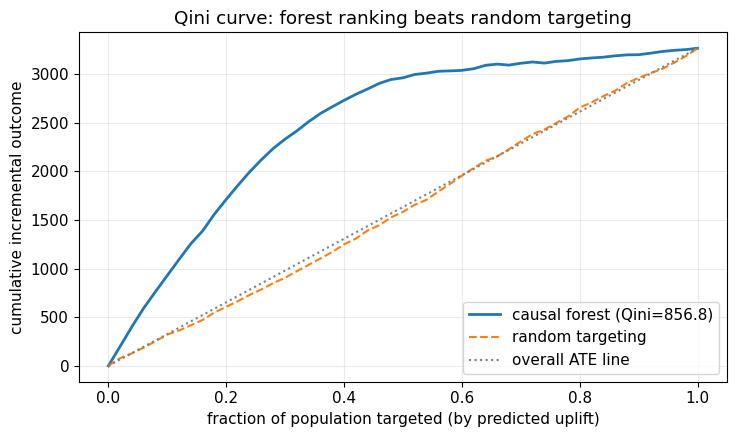

In [6]:
def qini_curve(tau_pred, T, Y, n_bins=50):
    '''Cumulative uplift as we target by descending predicted effect.
       Uses the standard Qini estimator from observed treated/control outcomes.'''
    order = np.argsort(-tau_pred)
    T, Y = T[order], Y[order]
    n = len(T)
    xs, ys = [0.0], [0.0]
    for frac in np.linspace(1/n_bins, 1, n_bins):
        k = int(frac*n)
        Tt, Yt = T[:k], Y[:k]
        n1 = max((Tt==1).sum(), 1); n0 = max((Tt==0).sum(), 1)
        # Qini: treated responders minus rescaled control responders
        uplift = Yt[Tt==1].sum() - Yt[Tt==0].sum()*(n1/n0)
        xs.append(frac); ys.append(uplift)
    return np.array(xs), np.array(ys)

def qini_coefficient(xs, ys):
    # area between curve and the straight line to its endpoint
    diag = ys[-1]*xs
    return (np.trapezoid if hasattr(np,"trapezoid") else np.trapz)(ys - diag, xs)

x_f, y_f = qini_curve(fpred, T, Y)
x_r, y_r = qini_curve(default_rng(1).normal(size=len(T)), T, Y)   # random targeting
q_model = qini_coefficient(x_f, y_f)
q_random = qini_coefficient(x_r, y_r)
print(f"Qini coefficient — causal forest : {q_model:.2f}")
print(f"Qini coefficient — random target : {q_random:.2f}")

plt.plot(x_f, y_f, label=f"causal forest (Qini={q_model:.1f})", lw=2)
plt.plot(x_r, y_r, label="random targeting", ls="--")
plt.plot([0,1],[0,y_f[-1]], color="gray", ls=":", label="overall ATE line")
plt.xlabel("fraction of population targeted (by predicted uplift)")
plt.ylabel("cumulative incremental outcome")
plt.title("Qini curve: forest ranking beats random targeting")
plt.legend(); plt.tight_layout(); plt.savefig("../figures/w5_qini.png", dpi=110); plt.show()

### Uplift by decile

A managerial view: bucket units into deciles of predicted effect and compare the *realized*
treated-minus-control difference in each. A well-calibrated CATE model produces a monotone
staircase. Because we control the simulator, we overlay the true mean CATE per decile.

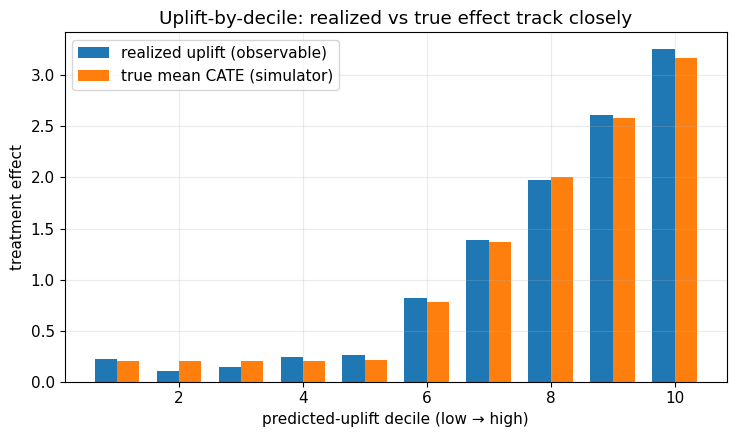

Monotone increase confirms the model ranks responsiveness correctly.


In [7]:
def uplift_by_decile(tau_pred, T, Y, true_tau=None, q=10):
    edges = np.quantile(tau_pred, np.linspace(0,1,q+1))
    edges[-1] += 1e-9
    realized, truth = [], []
    for i in range(q):
        m = (tau_pred >= edges[i]) & (tau_pred < edges[i+1])
        Tt, Yt = T[m], Y[m]
        realized.append(Yt[Tt==1].mean() - Yt[Tt==0].mean())
        if true_tau is not None: truth.append(true_tau[m].mean())
    return np.array(realized), (np.array(truth) if true_tau is not None else None)

real, truth = uplift_by_decile(fpred, T, Y, true_tau=TAU)
xq = np.arange(1, 11)
plt.bar(xq-0.18, real, width=.36, label="realized uplift (observable)")
plt.bar(xq+0.18, truth, width=.36, label="true mean CATE (simulator)")
plt.xlabel("predicted-uplift decile (low → high)"); plt.ylabel("treatment effect")
plt.title("Uplift-by-decile: realized vs true effect track closely")
plt.legend(); plt.tight_layout(); plt.savefig("../figures/w5_decile.png", dpi=110); plt.show()
print("Monotone increase confirms the model ranks responsiveness correctly.")

## Summary & what's next

- The **CATE** $\tau(x)$ is the object that drives targeting, personalized medicine, and
  policy — averages can be actively misleading.
- We built an **honest causal tree** that splits for *effect heterogeneity* (not outcome
  variance) and a bagged **causal forest** that recovered the true CATE surface with high
  rank-correlation.
- Because individual effects are unobservable, we evaluated with **uplift tooling** — the
  **Qini curve/coefficient** and **uplift-by-decile** — and verified against the simulator
  that these observable metrics track true performance.

**Exercises.** (1) Add confounding (non-random $T$) and combine the causal forest with
Week-3 propensity weighting in the leaf-effect estimates. (2) Implement the **AUUC** (area
under the uplift curve) and compare to Qini. (3) Use the forest's CATE to derive a treatment
**policy** and estimate its value with the Week-4 DML-AIPW score.

**Week 6:** when unconfoundedness *fails* — **instrumental variables**, **regression
discontinuity**, **difference-in-differences**, **sensitivity analysis**, and the capstone.